In [ ]:
import glob, os, re

import os
import numpy as np

import os, numpy as np, warnings

def load_run_bin_safe(path, allow_truncate=True):
    try:
        # obtiene el tamaño total del archivo en bytes
        size = os.path.getsize(path)

        # abrimos el archivo en modo binario para leer el header
        with open(path, "rb") as f:

            # N -> tamaño de la red (matriz NxN)
            N = np.fromfile(f, np.int32, 1)[0]

            # M_hdr -> número de matrices que el header dice que hay
            M_hdr = np.fromfile(f, np.int32, 1)[0]

            # alpha inicial
            alpha0 = np.fromfile(f, np.float64, 1)[0]

            # incremento de alpha entre matrices consecutivas
            dalpha = np.fromfile(f, np.float64, 1)[0]

            # posición actual del puntero → aquí empieza el bloque de matrices
            offset = f.tell()

        # cada matriz ocupa N*N bytes (uint8 = 1 byte)
        bytes_per_mat = int(N)*int(N)

        # tamaño real del bloque de datos
        payload = size - offset

        if payload <= 0:
            warnings.warn(f"{path}: fichero demasiado pequeño. Saltando.")
            return None

        # número REAL de matrices completas que caben en el archivo
        M_real = payload // bytes_per_mat

        # resto de bytes → si no es 0, el archivo está truncado
        rem = payload % bytes_per_mat

        if rem != 0:
            msg = f"{path}: TRUNCADO (M_completas={M_real}, resto={rem} bytes)."
            if allow_truncate:
                # seguimos adelante ignorando la parte corrupta
                warnings.warn(msg + " Recorto a matrices completas.")
            else:
                warnings.warn(msg + " Saltando fichero.")
                return None

        if M_real <= 0:
            warnings.warn(f"{path}: no contiene matrices completas. Saltando.")
            return None

        # si el header no coincide con lo que realmente hay en disco,
        # confiamos en el tamaño real
        if M_real != M_hdr:
            warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")

        # memmap permite acceder al archivo SIN cargarlo entero en RAM
        # Esto es MUY importante si las redes son grandes.
        mats = np.memmap(path, dtype=np.uint8, mode="r", offset=offset, shape=(M_real, N, N))

        # reconstruimos el vector alpha:
        # alpha_i = alpha0 + i * dalpha
        alpha = alpha0 + dalpha*np.arange(M_real)

        return alpha, mats

    except Exception as e:
        # si cualquier cosa falla, no rompe el programa
        warnings.warn(f"{path}: error al leer ({e}). Saltando.")
        return None


def export_bin_to_txt(bin_path, limit=None):
    """
    Exporta las matrices de un fichero .bin a archivos .txt.
    
    Solo necesitas pasar el nombre del fichero .bin.
    
    Ejemplo:
        export_bin_to_txt("adjacency_matrix_agg_nc25_s0.10.bin")
    """

    # nombre base del fichero sin extensión
    base_name = os.path.splitext(os.path.basename(bin_path))[0]

    # carpeta de salida automática
    out_dir = "created_networks/" + base_name + "_txt"
    os.makedirs(out_dir, exist_ok=True)

    # cargar matrices
    out = load_run_bin_safe(bin_path, allow_truncate=False)
    if out is None:
        raise ValueError(f"No se pudo leer: {bin_path}")

    alpha, mats = out

    M = len(alpha)
    if limit is not None:
        M = min(M, int(limit))

    saved = []

    for i in range(M):

        a = float(alpha[i])
        A = np.array(mats[i], dtype=np.uint8)

        alpha_tag = f"{a:.3f}"

        out_path = os.path.join(
            out_dir,
            f"adjacency_a{alpha_tag}.txt"
        )

        np.savetxt(out_path, A, fmt="%.0f")

        saved.append(out_path)

    print(f"{len(saved)} matrices exportadas en: {out_dir}")

    return saved

export_bin_to_txt("created_networks/adjacency_matrix_random_L3.0_l1.00.bin")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16812\2703139570.py:63: UserWarning: created_networks/adjacency_matrix_random_L3.0_l1.00.bin: M header=11, M real=10. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")


10 matrices exportadas en: created_networks/adjacency_matrix_random_L3.0_l1.00_txt


['created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.100.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.110.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.120.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.130.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.140.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.150.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.160.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.170.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.180.txt',
 'created_networks/adjacency_matrix_random_L3.0_l1.00_txt\\adjacency_a0.190.txt']

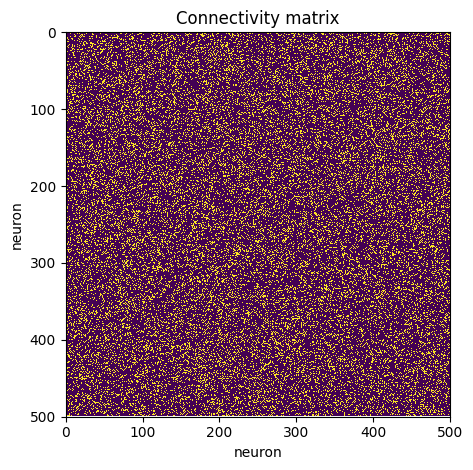

In [41]:
# 1) NETWORK SIZE
Ne = 400
Ni = 100
N = Ne + Ni
SIM_TIME = 3000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

# 3) Connectivity matrix A (Erdos-Renyi dirigido)
frac_delete = 0.8
A = np.random.rand(N, N)
A[A < frac_delete] = 0
A[A > 0] = 1
np.fill_diagonal(A, 0)

# Plot connectivity matrix (como tu script)
plt.figure()
plt.imshow(A, aspect='equal', interpolation='nearest')
plt.xlim(0, 500)
plt.ylim(500, 0)   # opcional: para que el 1 quede arriba; quita si no quieres
plt.xlabel('neuron')
plt.ylabel('neuron')
plt.title('Connectivity matrix')
plt.tight_layout()
plt.show()

# 4) Synaptic weights
MAX_EXC_WEIGTH = 4
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

# 5) Final weighted directed connectivity
S = A * W

# 6) Noise strength
NOISE_MAX = 3


In [16]:
import networkx as nx
N = 500
p = 0.2
ER = nx.erdos_renyi_graph(N, p, directed=True)
mean_degree = ER.number_of_edges() / N
print(f"Grado medio esperado: {mean_degree:.2f}")

Grado medio esperado: 100.52


Shape: (1200, 1200)
k =  86.1125


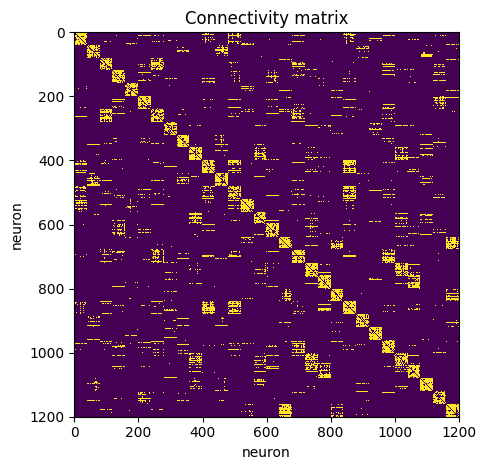

In [96]:
import numpy as np
import os
import matplotlib.pyplot as plt 

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

def connectivity_from_A(A: np.ndarray):
    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "A debe ser cuadrada"
    N = A.shape[0]

    # por si acaso
    A = A.copy()
    np.fill_diagonal(A, 0)

    E = A.sum()                 # número de enlaces (dirigidos)
    C = E / (N * (N - 1))       # densidad
    k_mean = E / N              # grado medio (out/in)

    return C, k_mean, E



# -------- USO --------

path = 'created_networks/adjacency_matrix_agg_nc30_s0.05_L2.0_rho300_l0.50_a0.200.txt'

A = load_A(path)
C, k, E = connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)


# Visualización
plt.figure()
plt.imshow(A, aspect='equal', interpolation='nearest')
plt.xlim(0, A.shape[0])
plt.ylim(A.shape[0], 0)
plt.xlabel('neuron')
plt.ylabel('neuron')
plt.title('Connectivity matrix')
plt.tight_layout()
plt.show()


# -------- Pesos --------

N = A.shape[0]

Ne = int(N*0.8)
Ni = int(N*0.2)
N = Ne + Ni

SIM_TIME = 3000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

MAX_EXC_WEIGTH = 3.5
MAX_INH_WEIGTH = 0.1

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

S = A * W
NOISE_MAX = 3

In [97]:
v = -65*np.ones((N, 1))
u = b * v

firings_t = []
firings_i = []

for t in range(1, SIM_TIME+1):
    I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

    fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

    if fired.size > 0:
        firings_t.append(np.full(fired.shape, t, dtype=int))
        firings_i.append(fired.copy())

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        # I = I + sum(S(:, fired), 2)
        # En numpy: sumamos columnas "fired" y nos queda vector Nx1
        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    # Integración (paso 0.5 ms x2)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    u = u + a*(b*v - u)

# Convertir lista de arrays a arrays planos
if len(firings_t) > 0:
    firings_t = np.concatenate(firings_t)
    firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
else:
    firings_t = np.array([], dtype=int)
    firings_i = np.array([], dtype=int)

print("Total spikes:", len(firings_t))


Total spikes: 9914


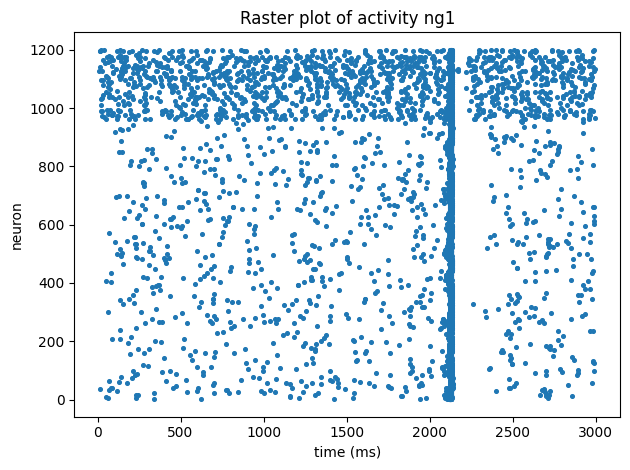

In [98]:
plt.figure()
plt.scatter(firings_t, firings_i, s=7)
plt.xlabel('time (ms)')
plt.ylabel('neuron')
plt.title('Raster plot of activity ng1')
plt.tight_layout()
plt.show()


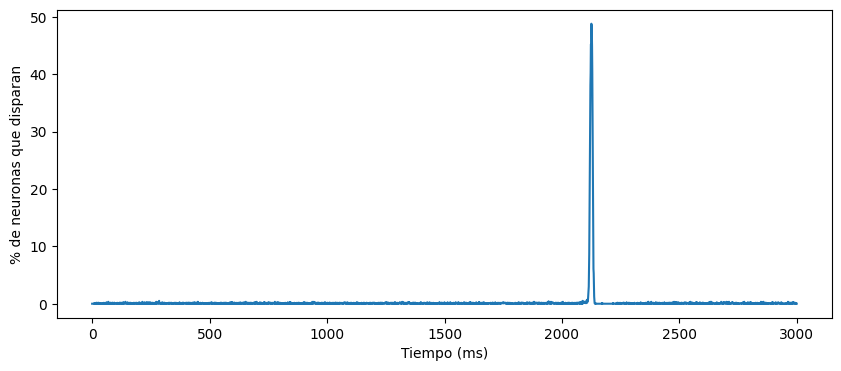

In [99]:
# spikes por timestep (vector de tamaño SIM_TIME+1)
spikes_per_t = np.bincount(firings_t, minlength=SIM_TIME+1)

# quitamos el índice 0 si tu simulación empieza en t=1
spikes_per_t = spikes_per_t[1:]

# porcentaje
percentage_firing = (spikes_per_t / N) * 100


import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(percentage_firing)
plt.xlabel("Tiempo (ms)")
plt.ylabel("% de neuronas que disparan")
# plt.xlim(2065, 2085)
plt.show()


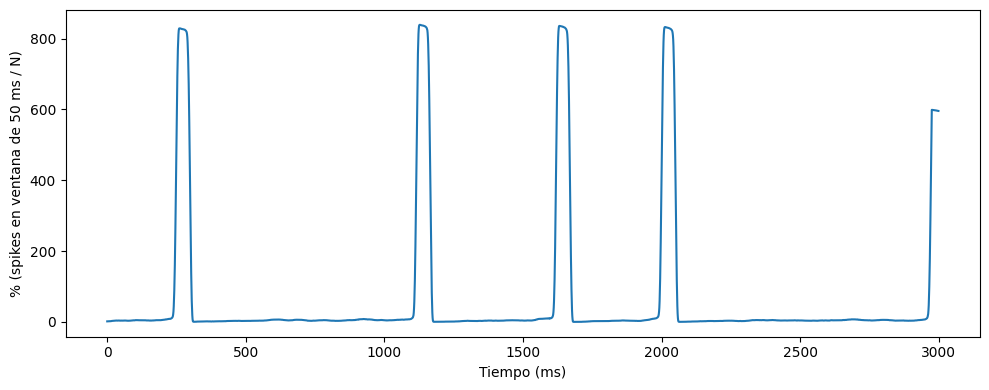

In [83]:
# spikes por timestep (ya lo tenías)
spikes_per_t = np.bincount(firings_t, minlength=SIM_TIME+1)[1:]  # t=1..SIM_TIME

W = 50  # ventana en ms (samples si dt=1ms)

# suma de spikes en ventana deslizante (convolución)
spikes_in_window = np.convolve(spikes_per_t, np.ones(W, dtype=int), mode="same")

# % de neuronas "equivalente": spikes en la ventana / N
# (ojo: puede superar 100% si hay neuronas que disparan varias veces en la ventana)
percentage_window = (spikes_in_window / N) * 100

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(percentage_window)
plt.xlabel("Tiempo (ms)")
plt.ylabel(f"% (spikes en ventana de {W} ms / N)")
plt.tight_layout()
plt.show()


In [84]:
SIM_TIME_SYNC = 1000
WINDOW = 100
num_active = np.zeros(10)

for j in range(1, 11):
    t0 = WINDOW*(j-1)
    t1 = WINDOW*j

    mask = (firings_t > t0) & (firings_t <= t1)
    neurons = firings_i[mask]
    if neurons.size == 0:
        num_active[j-1] = 0
    else:
        num_active[j-1] = len(np.unique(neurons)) / (Ne + Ni)

sync = np.max(num_active)
print("sync =", sync)
print("num_active per window =", num_active)


sync = 0.158
num_active per window = [0.056 0.064 0.09  0.068 0.106 0.086 0.158 0.074 0.08  0.15 ]


Shape: (1200, 1200)
k =  43.6725
Shape: (2400, 2400)
k =  4.970416666666667


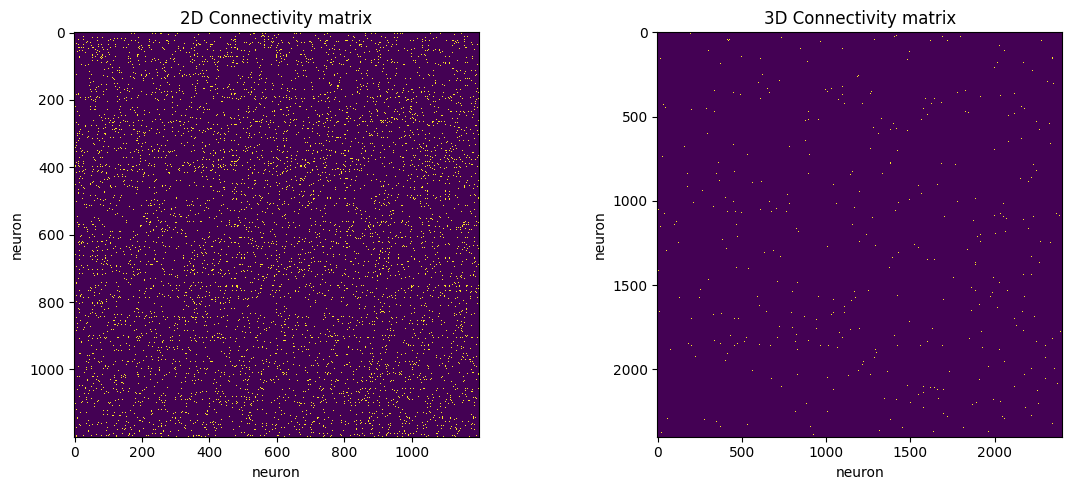

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt 

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

def connectivity_from_A(A: np.ndarray):
    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "A debe ser cuadrada"
    N = A.shape[0]

    # por si acaso
    A = A.copy()
    np.fill_diagonal(A, 0)

    E = A.sum()                 # número de enlaces (dirigidos)
    C = E / (N * (N - 1))       # densidad
    k_mean = E / N              # grado medio (out/in)

    return C, k_mean, E



# -------- USO --------

path2D = '2D_created_networks/2D_adjacency_matrix_random_L2.0_rho300_l1.00_a0.200.txt'
path3D = '3D_created_networks/3D_adjacency_matrix_random_L2.0_rho300_l1.00_a0.200.txt'

A2D = load_A(path2D)
C, k, E = connectivity_from_A(A2D)

print("Shape:", A2D.shape)
print('k = ', k)

A3D = load_A(path3D)
C, k, E = connectivity_from_A(A3D)

print("Shape:", A3D.shape)
print('k = ', k)

# Visualización

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(A2D, aspect='equal', interpolation='nearest')
axs[0].set_title('2D Connectivity matrix')
axs[0].set_xlabel('neuron')
axs[0].set_ylabel('neuron')

axs[1].imshow(A3D, aspect='equal', interpolation='nearest')
axs[1].set_title('3D Connectivity matrix')
axs[1].set_xlabel('neuron')
axs[1].set_ylabel('neuron')

plt.tight_layout()
plt.show()
